# GNN 기반 사기 리뷰 탐지 — [5] RGCN vs PC-GNN

| 모델 | 피처 | 엣지 | 특징 |
|------|------|------|------|
| **RGCN** | rating_norm 1개 | R-U-R 1종 | 단순 베이스라인 |
| **PC-GNN** | 전체 7개 | R-U-R + R-P-R + R-T-R | Picker + Chooser |

**평가지표**: PR-AUC, Macro F1

In [2]:
import sys, os
from pathlib import Path

# 노트북 실행 위치를 작업 디렉토리로 자동 설정 (하드코딩 제거)
_DIR = str(Path().resolve())
if _DIR not in sys.path:
    sys.path.insert(0, _DIR)
os.chdir(_DIR)
print('Working dir:', os.getcwd())

Working dir: C:\Users\bella\Desktop\대학\CODE\GNN 학술제


In [3]:
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv
from torch_geometric.utils import dropout_edge
from sklearn.metrics import average_precision_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.stats import entropy as sp_entropy
import matplotlib.pyplot as plt
from common_utils import setup_plotting

warnings.filterwarnings('ignore')
setup_plotting()
device = torch.device('cpu')
print(f'PyTorch {torch.__version__} | Device: {device}')

Plotting setup complete for Windows (Font: Malgun Gothic)
PyTorch 2.11.0+cpu | Device: cpu


## 1. 데이터 및 피처 로드

In [4]:
df = pd.read_parquet('yelpzip_sampled.parquet')
df['date'] = pd.to_datetime(df['date'])
df = df.reset_index(drop=True)

# 별점 피처 병합
feat_r = pd.read_csv('features_rating.csv')
df = df.merge(
    feat_r[['user_id','prod_id','rating_deviation','norm_rating_entropy',
            'is_cold_start','is_single_review']],
    on=['user_id','prod_id'], how='left'
)
df['rating_norm'] = df['rating'] / 5.0
feature_cols = ['rating_norm','rating_deviation','norm_rating_entropy',
                'is_cold_start','is_single_review']

# 버스트 피처 병합
if os.path.exists('burst_features.csv'):
    burst = pd.read_csv('burst_features.csv')
    df = df.merge(burst[['user_id','user_burst_max7d','user_burst_ratio']],
                  on='user_id', how='left')
    df[['user_burst_max7d','user_burst_ratio']] = \
        df[['user_burst_max7d','user_burst_ratio']].fillna(0)
    feature_cols += ['user_burst_max7d','user_burst_ratio']

df[feature_cols] = df[feature_cols].fillna(0)
print(f'Reviews: {len(df):,} | Fraud: {df["label"].mean():.1%}')
print(f'피처 {len(feature_cols)}개: {feature_cols}')

Reviews: 50,950 | Fraud: 24.8%
피처 7개: ['rating_norm', 'rating_deviation', 'norm_rating_entropy', 'is_cold_start', 'is_single_review', 'user_burst_max7d', 'user_burst_ratio']


## 2. 그래프 엣지 구성

In [5]:
df['review_idx'] = df.index

def build_pair_edges(series, max_per_group=150):
    rng = np.random.default_rng(42)
    src_list, dst_list = [], []
    for reviews in series:
        if len(reviews) < 2: continue
        if len(reviews) > max_per_group:
            reviews = rng.choice(reviews, max_per_group, replace=False)
        n = len(reviews)
        i, j = np.triu_indices(n, k=1)
        src_list.append(np.concatenate([reviews[i], reviews[j]]))
        dst_list.append(np.concatenate([reviews[j], reviews[i]]))
    if not src_list:
        return torch.zeros(2, 0, dtype=torch.long)
    return torch.from_numpy(np.stack([
        np.concatenate(src_list), np.concatenate(dst_list)
    ])).long()

rur_edge = build_pair_edges(
    df.groupby('user_id')['review_idx'].apply(np.array), max_per_group=50)
rpr_edge = build_pair_edges(
    df.groupby('prod_id')['review_idx'].apply(np.array), max_per_group=150)
te       = pd.read_csv('custom_edges_textSim.csv')
s, d     = te['src_review_idx'].values, te['dst_review_idx'].values
rtr_edge = torch.from_numpy(np.stack([
    np.concatenate([s,d]), np.concatenate([d,s])
])).long()

print(f'R-U-R: {rur_edge.shape[1]:,}  R-P-R: {rpr_edge.shape[1]:,}  R-T-R: {rtr_edge.shape[1]:,}')

# RGCN: R-U-R만 (유저단위 분할 → train-test 신호 차단)
rgcn_ei = rur_edge
rgcn_et = torch.zeros(rur_edge.size(1), dtype=torch.long)

# PC-GNN: 3종 전부
pc_edges = [rur_edge, rpr_edge, rtr_edge]
pc_ei = torch.cat(pc_edges, dim=1)
pc_et = torch.cat([torch.full((e.size(1),), i, dtype=torch.long)
                   for i, e in enumerate(pc_edges)])
print(f'RGCN  엣지: {rgcn_ei.shape[1]:,}개 (R-U-R 1종)')
print(f'PC-GNN 엣지: {pc_ei.shape[1]:,}개 (3종)')

R-U-R: 276,596  R-P-R: 4,236,552  R-T-R: 319,670
RGCN  엣지: 276,596개 (R-U-R 1종)
PC-GNN 엣지: 4,832,818개 (3종)


## 3. Train/Val/Test 분할 및 피처 텐서

In [6]:
np.random.seed(42)
users = df['user_id'].unique()
np.random.shuffle(users)
n_u = len(users)
train_u = set(users[:int(0.70*n_u)])
val_u   = set(users[int(0.70*n_u):int(0.85*n_u)])
test_u  = set(users[int(0.85*n_u):])

tr = torch.tensor(df['user_id'].isin(train_u).values, dtype=torch.bool)
va = torch.tensor(df['user_id'].isin(val_u).values,   dtype=torch.bool)
te = torch.tensor(df['user_id'].isin(test_u).values,  dtype=torch.bool)
print(f'Train: {tr.sum():,} | Val: {va.sum():,} | Test: {te.sum():,}')

# Train 기반 피처 재계산 (누수 방지)
train_df = df[tr.numpy()]

def norm_entropy(r):
    n = len(r)
    if n <= 1: return 0.5
    c = pd.Series(r).value_counts(normalize=True).values
    return float(sp_entropy(c) / np.log(n))

df['norm_rating_entropy'] = df['user_id'].map(
    train_df.groupby('user_id')['rating'].apply(norm_entropy)).fillna(0.5)

if 'user_burst_max7d' in feature_cols:
    def burst_max7(grp):
        dates = grp.sort_values('date')['date'].values
        if len(dates) < 2: return 1
        best = 1
        for d in dates:
            cnt = int(np.sum((dates >= d) &
                             (dates <= d + np.timedelta64(7,'D'))))
            best = max(best, cnt)
        return best
    burst_tr = train_df.groupby('user_id').apply(burst_max7)
    total_tr = train_df.groupby('user_id').size()
    df['user_burst_max7d'] = df['user_id'].map(burst_tr).fillna(0)
    df['user_burst_ratio'] = df['user_id'].map(
        burst_tr / total_tr.clip(lower=1)).fillna(0)

prod_mean = train_df.groupby('prod_id')['rating'].mean()
df['rating_deviation'] = df['rating'] - \
    df['prod_id'].map(prod_mean).fillna(train_df['rating'].mean())

# PC-GNN 피처 (7개)
sc = StandardScaler()
X = df[feature_cols].values.astype(float)
sc.fit(X[tr.numpy()])
x_pc = torch.tensor(sc.transform(X), dtype=torch.float)

# RGCN 피처 (rating_norm 1개)
sc_r = StandardScaler()
Xr = df[['rating_norm']].values.astype(float)
sc_r.fit(Xr[tr.numpy()])
x_r = torch.tensor(sc_r.transform(Xr), dtype=torch.float)

y = torch.tensor(df['label'].values, dtype=torch.long)
print(f'x_r  shape: {x_r.shape}  (RGCN — rating_norm 1개)')
print(f'x_pc shape: {x_pc.shape} (PC-GNN — 전체 {len(feature_cols)}개)')

Train: 35,347 | Val: 7,788 | Test: 7,815
x_r  shape: torch.Size([50950, 1])  (RGCN — rating_norm 1개)
x_pc shape: torch.Size([50950, 7]) (PC-GNN — 전체 7개)


## 4. RGCN 베이스라인

In [7]:
class RGCN(nn.Module):
    def __init__(self, in_f, hidden=32, drop=0.5):
        super().__init__()
        self.conv = RGCNConv(in_f, hidden, num_relations=1)
        self.clf  = nn.Linear(hidden, 2)
        self.drop = drop
    def forward(self, x, ei, et):
        h = F.relu(self.conv(x, ei, et))
        return self.clf(F.dropout(h, self.drop, training=self.training))

# 텐서 디바이스 이동
xr_d  = x_r.to(device);   xpc_d = x_pc.to(device)
y_d   = y.to(device)
rei_d = rgcn_ei.to(device); ret_d = rgcn_et.to(device)
pei_d = pc_ei.to(device);   pet_d = pc_et.to(device)
tr_d  = tr.to(device);      va_d  = va.to(device);  te_d = te.to(device)
eds_d = [e.to(device) for e in pc_edges]

def score(prob, pred, true):
    return average_precision_score(true, prob), f1_score(true, pred, average='macro')

model_r = RGCN(x_r.size(1)).to(device)
opt_r   = torch.optim.Adam(model_r.parameters(), lr=0.01, weight_decay=1e-4)
crit_r  = nn.CrossEntropyLoss()

best_vr, best_sr = 0.0, None
for ep in range(1, 201):
    model_r.train(); opt_r.zero_grad()
    loss = crit_r(model_r(xr_d, rei_d, ret_d)[tr_d], y_d[tr_d])
    loss.backward(); opt_r.step()
    if ep % 40 == 0:
        model_r.eval()
        with torch.no_grad():
            lg = model_r(xr_d, rei_d, ret_d)
            pr, f1 = score(
                F.softmax(lg[va_d],-1)[:,1].cpu().numpy(),
                lg[va_d].argmax(-1).cpu().numpy(),
                y_d[va_d].cpu().numpy())
        print(f'[RGCN] ep{ep:3d}  val PR-AUC={pr:.4f}  F1={f1:.4f}')
        if pr > best_vr:
            best_vr = pr
            best_sr = {k:v.clone() for k,v in model_r.state_dict().items()}

model_r.load_state_dict(best_sr)
model_r.eval()
with torch.no_grad():
    lg = model_r(xr_d, rei_d, ret_d)
    rgcn_pr, rgcn_f1 = score(
        F.softmax(lg[te_d],-1)[:,1].cpu().numpy(),
        lg[te_d].argmax(-1).cpu().numpy(),
        y_d[te_d].cpu().numpy())
print(f'\n[RGCN] Test  PR-AUC={rgcn_pr:.4f}  Macro F1={rgcn_f1:.4f}')

[RGCN] ep 40  val PR-AUC=0.5218  F1=0.4341
[RGCN] ep 80  val PR-AUC=0.5971  F1=0.5103
[RGCN] ep120  val PR-AUC=0.6385  F1=0.5110
[RGCN] ep160  val PR-AUC=0.6328  F1=0.5110
[RGCN] ep200  val PR-AUC=0.6469  F1=0.5110

[RGCN] Test  PR-AUC=0.6568  Macro F1=0.5104


## 5. PC-GNN 메인 모델
**Picker** — 사기 전체 + 3× 정상 샘플링  
**Chooser** — 릴레이션별 어텐션으로 위장 이웃 억제  
class-weighted loss + DropEdge

In [8]:
def scatter_wmean(vals, w, idx, n):
    out = torch.zeros(n, vals.size(-1), device=vals.device)
    cnt = torch.zeros(n, device=vals.device)
    out.scatter_add_(0, idx.unsqueeze(-1).expand_as(vals*w.unsqueeze(-1)), vals*w.unsqueeze(-1))
    cnt.scatter_add_(0, idx, w)
    return out / cnt.unsqueeze(-1).clamp(min=1e-8)

class Chooser(nn.Module):
    def __init__(self, f):
        super().__init__()
        self.att = nn.Linear(f*2, 1)
    def forward(self, x, ei, n):
        src, dst = ei
        a = torch.sigmoid(self.att(torch.cat([x[dst], x[src]], -1))).squeeze(-1)
        return scatter_wmean(x[src], a, dst, n)

class PCLayer(nn.Module):
    def __init__(self, in_f, out_f, drop=0.5):
        super().__init__()
        self.ch  = nn.ModuleList([Chooser(in_f) for _ in range(3)])
        self.lin = nn.Linear(in_f*4, out_f)
        self.drop = drop
    def forward(self, x, edges):
        n = x.size(0)
        h = F.relu(self.lin(torch.cat([x]+[c(x,e,n) for c,e in zip(self.ch,edges)],-1)))
        return F.dropout(h, self.drop, training=self.training)

class PCGNN(nn.Module):
    def __init__(self, in_f, hid=64, drop=0.5):
        super().__init__()
        self.l1  = PCLayer(in_f, hid, drop)
        self.l2  = PCLayer(hid, hid//2, drop)
        self.clf = nn.Linear(hid//2, 2)
    def forward(self, x, edges):
        return self.clf(self.l2(self.l1(x, edges), edges))

def picker(y, mask, ratio=3):
    idx = mask.nonzero(as_tuple=True)[0]
    fraud = idx[y[idx]==1]
    normal = idx[y[idx]==0]
    k = min(len(fraud)*ratio, len(normal))
    chosen = normal[torch.randperm(len(normal), device=normal.device)[:k]]
    return torch.cat([fraud, chosen])

print('PC-GNN 정의 완료')

PC-GNN 정의 완료


In [9]:
fw       = (y==0).sum().float() / (y==1).sum().float()
crit_pc  = nn.CrossEntropyLoss(weight=torch.tensor([1.0, fw.item()]).to(device))
model_pc = PCGNN(x_pc.size(1)).to(device)
opt_pc   = torch.optim.Adam(model_pc.parameters(), lr=0.005, weight_decay=1e-4)

best_vp, best_sp = 0.0, None
for ep in range(1, 201):
    model_pc.train(); opt_pc.zero_grad()
    ed = [dropout_edge(e, p=0.2, force_undirected=True, training=True)[0] for e in eds_d]
    picked = picker(y_d, tr_d, ratio=3)
    loss   = crit_pc(model_pc(xpc_d, ed)[picked], y_d[picked])
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model_pc.parameters(), 1.0)
    opt_pc.step()
    if ep % 40 == 0:
        model_pc.eval()
        with torch.no_grad():
            lg = model_pc(xpc_d, eds_d)
            pr, f1 = score(
                F.softmax(lg[va_d],-1)[:,1].cpu().numpy(),
                lg[va_d].argmax(-1).cpu().numpy(),
                y_d[va_d].cpu().numpy())
        print(f'[PC-GNN] ep{ep:3d}  val PR-AUC={pr:.4f}  F1={f1:.4f}')
        if pr > best_vp:
            best_vp = pr
            best_sp = {k:v.clone() for k,v in model_pc.state_dict().items()}

model_pc.load_state_dict(best_sp)
model_pc.eval()
with torch.no_grad():
    lg = model_pc(xpc_d, eds_d)
    pc_pr, pc_f1 = score(
        F.softmax(lg[te_d],-1)[:,1].cpu().numpy(),
        lg[te_d].argmax(-1).cpu().numpy(),
        y_d[te_d].cpu().numpy())
print(f'\n[PC-GNN] Test  PR-AUC={pc_pr:.4f}  Macro F1={pc_f1:.4f}')

[PC-GNN] ep 40  val PR-AUC=0.8701  F1=0.7109
[PC-GNN] ep 80  val PR-AUC=0.8774  F1=0.4569
[PC-GNN] ep120  val PR-AUC=0.8619  F1=0.4580
[PC-GNN] ep160  val PR-AUC=0.8276  F1=0.4602
[PC-GNN] ep200  val PR-AUC=0.6961  F1=0.4530

[PC-GNN] Test  PR-AUC=0.8496  Macro F1=0.4561


## 6. 결과 비교

          Model   PR-AUC  Macro F1
RGCN (Baseline) 0.656781  0.510401
  PC-GNN (Main) 0.849628  0.456116


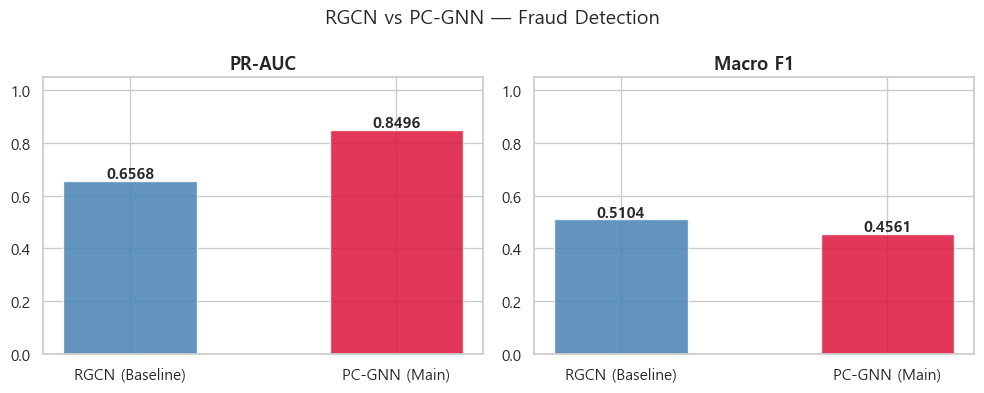

=== RGCN 상세 리포트 ===
              precision    recall  f1-score   support

      Normal       0.77      0.99      0.87      5880
       Fraud       0.80      0.09      0.15      1935

    accuracy                           0.77      7815
   macro avg       0.78      0.54      0.51      7815
weighted avg       0.78      0.77      0.69      7815

=== PC-GNN 상세 리포트 ===
              precision    recall  f1-score   support

      Normal       0.76      1.00      0.86      5880
       Fraud       1.00      0.03      0.05      1935

    accuracy                           0.76      7815
   macro avg       0.88      0.51      0.46      7815
weighted avg       0.82      0.76      0.66      7815



In [10]:
results = pd.DataFrame({
    'Model'   : ['RGCN (Baseline)', 'PC-GNN (Main)'],
    'PR-AUC'  : [rgcn_pr, pc_pr],
    'Macro F1': [rgcn_f1, pc_f1]
})
print('='*45)
print(results.to_string(index=False))
print('='*45)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['steelblue', 'crimson']
for ax, col in zip(axes, ['PR-AUC', 'Macro F1']):
    bars = ax.bar(results['Model'], results[col], color=colors, alpha=0.85, width=0.5)
    ax.set_ylim(0, 1.05)
    ax.set_title(col, fontsize=13, fontweight='bold')
    for bar, v in zip(bars, results[col]):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.01,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.suptitle('RGCN vs PC-GNN — Fraud Detection', fontsize=14)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== RGCN 상세 리포트 ===')
with torch.no_grad():
    lg_r = model_r(xr_d, rei_d, ret_d)
    pred_r = lg_r[te_d].argmax(-1).cpu().numpy()
true_te = y_d[te_d].cpu().numpy()
print(classification_report(true_te, pred_r, target_names=['Normal','Fraud']))

print('=== PC-GNN 상세 리포트 ===')
with torch.no_grad():
    lg_p = model_pc(xpc_d, eds_d)
    pred_p = lg_p[te_d].argmax(-1).cpu().numpy()
print(classification_report(true_te, pred_p, target_names=['Normal','Fraud']))